In [10]:
# Quiz 7.1

from numpy.linalg import inv
import numpy as np
from numpy import linalg as la

M = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
print("M=")
print(M)

det = la.det(M)
print(f"Determinant of M is: {det}")

b = np.array([2,2,1]) 

Minv = inv(M)
xyz = Minv@b
print(f"\nSolution: x, y, z = {xyz}")

if np.dot(M[0],M[1]) == 0:
    if np.dot(M[1],M[2]) == 0:
        print('M is orthogolan')
else:
    print('M is not orthogonal')

Lambda, v = la.eig(M)
print("Lambda = ", Lambda)
print(f"\nEigenvectors:\n{v}")

M=
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
Determinant of M is: 1.0

Solution: x, y, z = [ 38.  -3. -10.]
M is not orthogonal
Lambda =  [ 1.         -4.79128785 -0.20871215]

Eigenvectors:
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


In [8]:
# Quiz 7.3

from numpy.linalg import inv
import numpy as np
from numpy import linalg as la
from math import pi,sqrt

def Ex(a):
    a = a/360*2*pi
    return np.array([1,0,0,0,np.cos(a),np.sin(a), 0,-np.sin(a),np.cos(a)]).reshape(3,3)
def Ey(b):
    b = b/360*2*pi
    return np.array([np.cos(b),0,-np.sin(b),0,1,0,np.sin(b),0,np.cos(b)]).reshape(3,3)
def Ez(c):
    c = c/360*2*pi
    return np.array([np.cos(c),np.sin(c),0,-np.sin(c),np.cos(c),0,0,0,1]).reshape(3,3)

E = (Ez(57)@Ey(62.6)@Ez(192.25))
print(E)

if np.allclose(inv(E),E.T):
    if la.det(E) == 1:
        print('E is a rotation matrix')
else:
    print('E is not a rotation matrix')

Lambda, v = la.eig(E)
v1, v2, v3 = v.T

print("Lambda = ", Lambda)
print(f"\nEigenvectors:\n{v}")
print(np.allclose(E@v2, Lambda[1]*v2))

def Ew(d,e):
    d = d/360*2*pi
    e = e/360*2*pi
    return np.array([np.cos(d)*np.cos(e), np.cos(d)*np.sin(e), np.sin(d)]).T

v = Ew(27.4,192.25)
print(v)

norm = sqrt(v[0]**2+v[1]**2+v[2]**2)
print(norm)

v2 = E@v
print(v2)

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
E is a rotation matrix
Lambda =  [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]

Eigenvectors:
[[ 0.09023842+0.58384315j  0.09023842-0.58384315j -0.54951651+0.j        ]
 [ 0.68877691+0.j          0.68877691-0.j          0.22621391+0.j        ]
 [-0.13207344+0.39890747j -0.13207344-0.39890747j  0.80427537+0.j        ]]
True
[-0.86760081 -0.1883746   0.46019978]
1.0
[ 5.55111512e-17 -5.55111512e-17  1.00000000e+00]


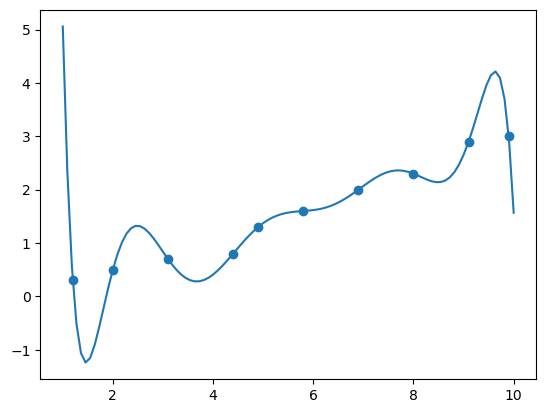

In [52]:
# Quiz 7.5

import numpy as np
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

X=[]
for i in range(len(x)):
    for j in range(1,len(y)+1):
        X.append(x[i]**(len(y)-j))
X = np.array(X).reshape(10,10)

a = np.linalg.solve(X,y)

x2 = np.linspace(1,10,100)
plt.scatter(x,y)
plt.plot(x2, np.polyval(a,x2))

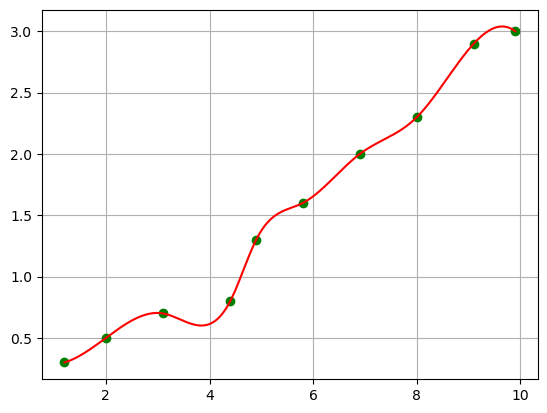

1.3731301578332022
1.3333333333333333
1.3744762382675273


In [23]:
# Quiz 7.6

import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(1.2,9.9,250)  # notice outside the original domain
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
show()

class interpolation:

    def __init__(self,x,y):
        x = np.array(x)
        y = np.array(y)
        fc = ip.interp1d(x, y, kind='cubic')
        fl = ip.interp1d(x,y, kind='linear')
        self.fc = fc
        self.fl = fl
        X=[]
        for i in range(len(x)):
            for j in range(1,len(y)+1):
                X.append(x[i]**(len(y)-j))
        X = np.array(X).reshape(-1,len(x))
        a = np.linalg.solve(X,y)
        self.a = a
        self.x = x
        
    def inter(self,b,kind):
        if kind == 'cubic':
            return self.fc(b)
        elif kind == 'linear':
            return self.fl(b)
        elif kind == 'poly':
            return np.polyval(self.a,b)
            

interpol = interpolation(x,y)
print(interpol.inter(5,kind='poly'))
print(interpol.inter(5,kind='linear'))
print(interpol.inter(5,kind='cubic'))

$\boxed{I_{ip}= (1-\lambda)(1-\mu)I_0 + \lambda(1-\mu)I_1 + \mu (1-\lambda)I_2+\lambda \mu I_3}$

In [27]:
# Quiz 7.7

import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x=0.2 
y=0.7
I = np.array([[2.0,4.1], [2.5,3.8]])

i = int(x)
j = int(y)

lamb = y - j
mu = x - 1

Iip = (1-lamb)*(1-mu)*I[0,0]+lamb*(1-mu)*I[0,1]+mu*(1-lamb)*I[1,0]+lamb*mu*I[1,1]
print(Iip)

3.5179999999999993


Intercept beta0=69.9377803016813, slope beta1=64.13234247590542
====== LEASTSQ RESULTS ==========
Params:                          [69.93805979 64.13233494]
Unscaled standard error(s):      [47.32288249  1.52711792]
Scaled standard error(s):        [348.23437453  11.23758582]
Degrees of freedom:              11
Chi^2 min:                       595.6533407328835
Reduced Chi squared:             54.15030370298941
Iterations:                      Not returned by leastsq()
Number of function evaluations:  7


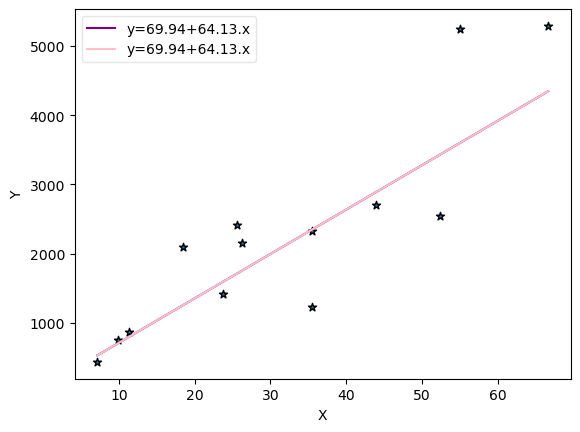

In [2]:
# Quiz 7.10

import pandas as pd
import numpy as np
from matplotlib.pyplot import subplots, show, figure
import matplotlib.pyplot as plt
from scipy.optimize import leastsq
from scipy.optimize import curve_fit


names=['d(Mpc)', 'v(km/s)', 'error in d', 'error in v']
data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]
data=np.reshape(data,(-1,4))

df = pd.DataFrame(data, columns=names)

x=df['d(Mpc)'].values
y=df['v(km/s)'].values
sigy=df['error in v'].values


def model(beta, x):
    beta0, beta1 = beta              # Parameters which are adjusted by leastsq
    return beta0 + beta1*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy


def model_c(x, beta0, beta1):
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*x

# Do the fitting
beta_c, pcov_c = curve_fit(model_c, x, y, sigma=sigy)
print(f"Intercept beta0={beta_c[0]}, slope beta1={beta_c[1]}")


# Calculate end points for the best straight line
X = np.array([x.min(),x.max()])
Y_c = model_c(X, beta_c[0], beta_c[1])

beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
data = (x, y, sigy)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results

if not pcov is None:
    # Note that 'fvec' are residuals, not function
    # values according to the documentation
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())        # Trusted as the weights are realistic
    dof = len(fvec) - len(beta)              # Number of degrees of freedom
    # Uncertainties for unweighted data
    sderr = perror * np.sqrt(chi2/dof)

print( "====== LEASTSQ RESULTS =========="          )
print( "Params:                         ", beta     )
print( "Unscaled standard error(s):     ", perror   )
print( "Scaled standard error(s):       ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Iterations:                     ", "Not returned by leastsq()" )
print( "Number of function evaluations: ", infodict['nfev'] )

beta_lsqwei = beta

Y = model_c(X, beta[0], beta[1])

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='*', ec='k')
frame.set_xlabel('X')
frame.set_ylabel('Y')
label = f"y={beta_c[0]:.2f}+{beta_c[1]:.2f}.x"
frame.plot(X, Y_c, label=label, color='purple')

label = f"y={beta[0]:.2f}+{beta[1]:.2f}.x"
frame.plot(X, Y, label=label, color='pink')
frame.legend(fancybox=True, framealpha=0.5)
#frame.grid(True)
show()

In [ ]:
# Quiz 7.14

